In [2]:
from Bio import SeqIO
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
import re

In [3]:
def prepare_segment_dataset(df_path, fasta_path):

    df = pd.read_csv(df_path)
    
    seq_dict = {r.id: str(r.seq) for r in SeqIO.parse(fasta_path, 'fasta')}
    
    df['Sequence'] = df['Accession'].map(seq_dict)

    unmatched_rows = df[df['Sequence'].isna()]
    
    if not unmatched_rows.empty:
        print(f'Upozorenje: Pronađeno je {len(unmatched_rows)} accession brojeva koji NISU pronađeni u FASTA fajlu:')
        print(unmatched_rows['Accession'].tolist())
    else:
        print('Svi accession brojevi su uspešno upareni sa FASTA fajlom!')
    
    df = df.dropna(subset=['Sequence'])
    
    df['Sequence'] = df['Sequence'].str.upper()
    ambiguous_pattern = '[^ACGT]'
    
    df_clean = df[~df['Sequence'].str.contains(ambiguous_pattern, regex=True)].copy()

    ambiguous_rows = df[df['Sequence'].str.contains(ambiguous_pattern, regex=True)].copy()

    def get_ambiguous_chars(seq):
        return set(re.findall(ambiguous_pattern, seq))
    
    ambiguous_rows['Found_Ambiguous'] = ambiguous_rows['Sequence'].apply(get_ambiguous_chars)

    if not ambiguous_rows.empty:
        print(ambiguous_rows[['Accession', 'Found_Ambiguous']])
    else:
        print("Nema pronađenih sekvenci sa ambivalentnim bazama.")
        
    print(f'Originalni broj redova: {len(df)}')
    print(f'Broj redova nakon čišćenja: {len(df_clean)}')
    
    return df_clean

Iako su hantavirusi jednolančani RNK virusi čiji genom sadrži uracil (U), NCBI Virus baza sekvence skladišti u standardnom cDNA formatu sa četvoroslovnom azbukom {A,C,G,T}. U skladu sa tim, analiza k-mera sprovedena je korišćenjem simbola T umesto U.

# Sve nukleotidne sekvence

In [4]:
hantaan_dataset = prepare_segment_dataset('../data/processed_sequences/all_sequences/hantaan_all.csv','../data/raw/hantaan.fasta')

Svi accession brojevi su uspešno upareni sa FASTA fajlom!
       Accession        Found_Ambiguous
87    PV848112.1                    {W}
181   OR684711.1  {K, W, M, R, H, Y, S}
388   OR239914.1                    {W}
660   MW349028.1                    {R}
896   MN608072.1                    {Y}
1056  MK189292.1                    {M}
1062  MK189298.1                    {R}
1137  MF141748.1                    {M}
1241  KY283955.1                 {R, Y}
1242  KY283956.1                    {R}
1264  KY357322.1                    {Y}
1404  KT934997.1                    {R}
1871  FJ844392.1                 {R, Y}
1985  EU092222.1                    {R}
2000  EF208930.1                 {M, R}
2069  AF288658.1           {R, M, Y, S}
2090  AB071183.1                 {R, Y}
2093  AB071186.1                    {Y}
2181  AF172424.1                    {Y}
Originalni broj redova: 2218
Broj redova nakon čišćenja: 2199


In [5]:
puumala_dataset = prepare_segment_dataset('../data/processed_sequences/all_sequences/puumala_all.csv','../data/raw/puumala.fasta')

Svi accession brojevi su uspešno upareni sa FASTA fajlom!
       Accession Found_Ambiguous
6     PQ867783.1             {R}
119   OR573657.1             {R}
121   OR581028.1             {R}
344   OP561828.1          {Y, W}
365   OP561849.1          {Y, W}
433   MZ580953.1             {S}
577   MZ014471.1             {R}
578   MZ014472.1             {R}
579   MZ014473.1             {R}
868   MZ343346.1          {R, V}
879   MZ343357.1             {R}
976   MW023667.1             {Y}
979   MW023670.1             {R}
987   MW023678.1             {R}
1012  MW023703.1             {Y}
1025  MW023716.1             {R}
1029  MW023720.1             {R}
1033  MW023724.1             {Y}
1036  MW023727.1          {R, Y}
1568  MN026221.1             {W}
1583  MN026236.1             {Y}
1600  MN026253.1             {K}
1616  MK770463.1          {R, K}
1621  MK770468.1             {R}
1623  MK770470.1             {M}
1630  MK770477.1          {Y, S}
1632  MK770479.1             {R}
1635  MK770482.1  

In [6]:
dobrava_dataset = prepare_segment_dataset('../data/processed_sequences/all_sequences/dobrava_all.csv','../data/raw/dobrava_belgrade.fasta')

Svi accession brojevi su uspešno upareni sa FASTA fajlom!
      Accession Found_Ambiguous
4    PX840724.1             {Y}
127  MK770453.1             {Y}
177  KY649165.1       {R, Y, W}
431  KJ437511.1             {R}
515  JQ026206.1       {R, K, Y}
576  GQ205409.1             {R}
695  AY961616.1             {R}
717  AY168576.1    {R, M, K, Y}
724  AJ269549.1    {R, M, K, Y}
725  AJ269550.1    {R, M, K, Y}
Originalni broj redova: 781
Broj redova nakon čišćenja: 771


In [7]:
sin_nombre_dataset = prepare_segment_dataset('../data/processed_sequences/all_sequences/sin_nombre_all.csv','../data/raw/sin_nombre.fasta')

Svi accession brojevi su uspešno upareni sa FASTA fajlom!
     Accession     Found_Ambiguous
9   PX401025.1                 {M}
19  OQ999111.1                 {M}
45  OQ999151.1              {K, S}
69  ON571584.1              {V, S}
70  ON571587.1                 {S}
72  ON571591.1                 {W}
75  MZ400487.1  {K, W, M, R, Y, S}
76  MZ400488.1                 {Y}
Originalni broj redova: 366
Broj redova nakon čišćenja: 358


In [8]:
print(f'Hantaan: {len(hantaan_dataset)} sekvenci')
print(f'Dobrava: {len(dobrava_dataset)} sekvenci')
print(f'Puumala: {len(puumala_dataset)} sekvenci')
print(f'Sin Nombre: {len(sin_nombre_dataset)} sekvenci')

Hantaan: 2199 sekvenci
Dobrava: 771 sekvenci
Puumala: 3625 sekvenci
Sin Nombre: 358 sekvenci


In [9]:
all_sequences = pd.concat([
    hantaan_dataset,
    dobrava_dataset,
    puumala_dataset,
    sin_nombre_dataset
], ignore_index=True)

In [10]:
print(f'Konačan broj redova datasetu: {len(all_sequences)}')

Konačan broj redova datasetu: 6953


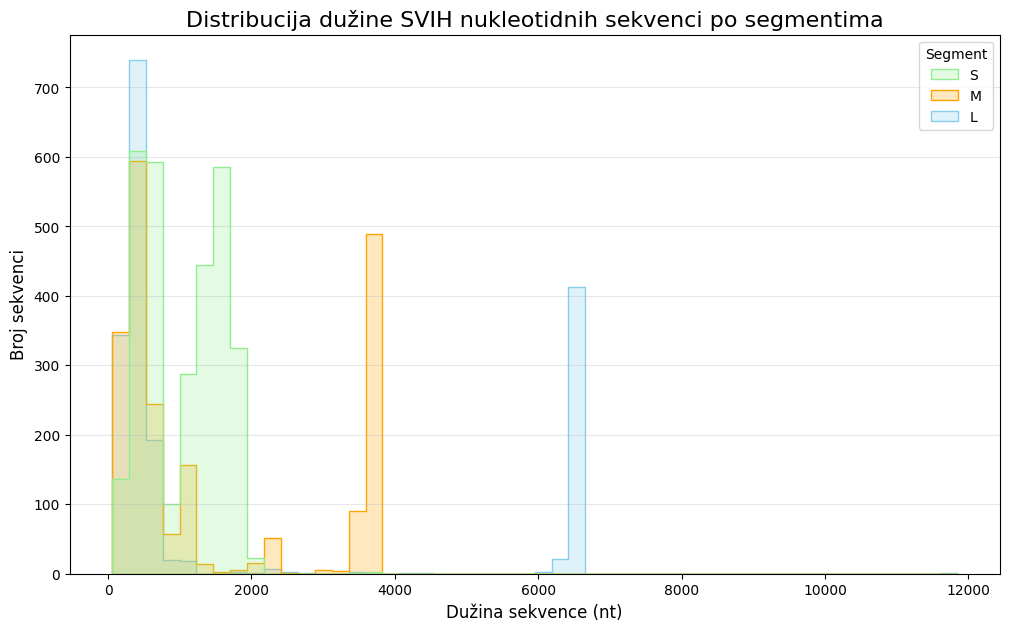

In [11]:
plt.figure(figsize=(12, 7))

sns.histplot(data=all_sequences, 
             x=all_sequences['Sequence'].str.len(), 
             hue='Segment', 
             bins=50, 
             kde=False,
             palette={'S': 'lightgreen', 'M': 'orange', 'L': 'skyblue'},
             element='step') 

plt.title('Distribucija dužine SVIH nukleotidnih sekvenci po segmentima', fontsize=16)
plt.xlabel('Dužina sekvence (nt)', fontsize=12)
plt.ylabel('Broj sekvenci', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [12]:
max_len = all_sequences['Sequence'].str.len().max()
print(f"Maksimalna dužina sekvence u datasetu je: {max_len} nt")

Maksimalna dužina sekvence u datasetu je: 11845 nt


In [13]:
anomalies = all_sequences[all_sequences['Sequence'].str.len() > 7000]
display(anomalies[['Accession', 'Segment', 'Nuc_Completeness', 'Species', 'Sequence']])

,Accession,Segment,Nuc_Completeness,Species,Sequence
1813,JN542542.1,L,partial,Orthohantavirus hantanense,TAGTAGTAGGCTCCCTAAAGAGCTACTATAACAACGATGGCAACTA...


In [14]:
MIN_LEN = 350   # donji prag za parcijalne sekvence (eliminiše dužinski šum)
MAX_LEN = 7000  

In [15]:
mask_valid = (all_sequences['Sequence'].str.len() >= MIN_LEN) & (all_sequences['Sequence'].str.len() <= MAX_LEN)

all_sequences_clean = all_sequences[mask_valid].copy()
noise_sequences = all_sequences[~mask_valid].copy()

print(f"Uklonjeno sekvenci koje čine šum: {len(noise_sequences)}")
print(f"Čist dataset spreman za k-mere: {len(all_sequences_clean)}")
print(f"Novi raspon dužina: {all_sequences_clean['Sequence'].str.len().min()} - {all_sequences_clean['Sequence'].str.len().max()} nt")

Uklonjeno sekvenci koje čine šum: 1774
Čist dataset spreman za k-mere: 5179
Novi raspon dužina: 350 - 6588 nt


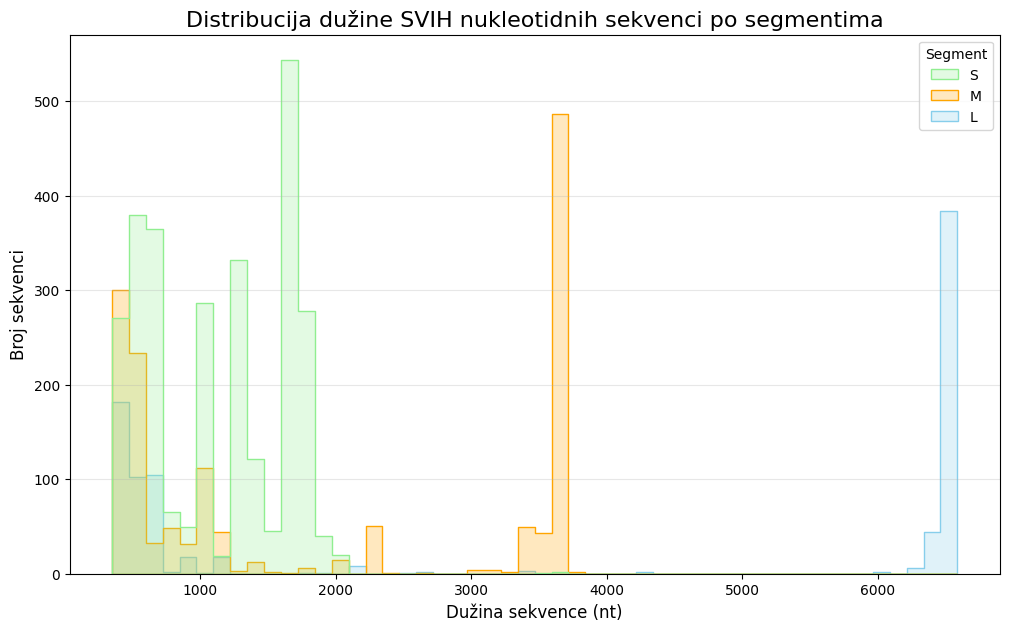

In [16]:
plt.figure(figsize=(12, 7))

sns.histplot(data=all_sequences_clean, 
             x=all_sequences['Sequence'].str.len(), 
             hue='Segment', 
             bins=50, 
             kde=False,
             palette={'S': 'lightgreen', 'M': 'orange', 'L': 'skyblue'},
             element='step') 

plt.title('Distribucija dužine SVIH nukleotidnih sekvenci po segmentima', fontsize=16)
plt.xlabel('Dužina sekvence (nt)', fontsize=12)
plt.ylabel('Broj sekvenci', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

Analiza distribucije dužina sekvenci po segmentima ukazuje na izrazitu heterogenost, što je posledica prisustva velikog broja parcijalnih izolata u NCBI bazi (sekvencirani samo kraći regioni sekvence). Uočljivo je da mnogi parcijalni fragmenti M i L segmenata (dužine 400–1.000 nt) imaju znatno manju dužinu od kompletnih sekvenci S segmenta (oko 1.700–1.800 nt), dok se njihove kanonske pune dužine jasno očitavaju u višim pikovima (oko 3.600 nt za M i oko 6.500 nt za L segment).Kako bi se obezbedila pouzdanost frekvencija $k$-mera, primenjen je filter dužine u rasponu od 350 do 7.000 nt. Donja granica od 350 nt eliminiše prekratke fragmente i prajmere čiji profil $k$-mera pati od visoke stohastičke varijanse usled malog uzorka, dok gornja granica od 7.000 nt uklanja konkatenirane zapise (poput zapisa JN542542.1 dužine 11.845 nt). Ovim korakom uklonjene su 1.774 nestandardne sekvence, pri čemu je zadržano 5.179 biološki upotrebljivih sekvenci (u rasponu od 350 do 6.588 nt) koje obuhvataju i parcijalne i kompletne izolate hantavirusnih segmenata.

# Kompletne nukleotidne sekvence

In [57]:
hantaan_complete_dataset = prepare_segment_dataset('../data/processed_sequences/complete_sequences/hantaan_complete.csv','../data/raw/hantaan.fasta')

Svi accession brojevi su uspešno upareni sa FASTA fajlom!
      Accession Found_Ambiguous
243  EF208930.1          {M, R}
Originalni broj redova: 250
Broj redova nakon čišćenja: 249


In [58]:
puumala_complete_dataset = prepare_segment_dataset('../data/processed_sequences/complete_sequences/puumala_complete.csv','../data/raw/puumala.fasta')

Svi accession brojevi su uspešno upareni sa FASTA fajlom!
     Accession Found_Ambiguous
6   OR573657.1             {R}
26  MZ014471.1             {R}
27  MZ014472.1             {R}
28  MZ014473.1             {R}
Originalni broj redova: 127
Broj redova nakon čišćenja: 123


In [59]:
dobrava_complete_dataset = prepare_segment_dataset('../data/processed_sequences/complete_sequences/dobrava_complete.csv','../data/raw/dobrava_belgrade.fasta')

Svi accession brojevi su uspešno upareni sa FASTA fajlom!
     Accession Found_Ambiguous
23  JQ026206.1       {K, Y, R}
32  GQ205409.1             {R}
Originalni broj redova: 40
Broj redova nakon čišćenja: 38


In [60]:
sin_nombre_complete_dataset = prepare_segment_dataset('../data/processed_sequences/complete_sequences/sin_nombre_complete.csv','../data/raw/sin_nombre.fasta')

Svi accession brojevi su uspešno upareni sa FASTA fajlom!
Nema pronađenih sekvenci sa ambivalentnim bazama.
Originalni broj redova: 18
Broj redova nakon čišćenja: 18


In [61]:
print(f'Hantaan: {len(hantaan_complete_dataset)} sekvenci')
print(f'Dobrava: {len(dobrava_complete_dataset)} sekvenci')
print(f'Puumala: {len(puumala_complete_dataset)} sekvenci')
print(f'Sin Nombre: {len(sin_nombre_complete_dataset)} sekvenci')

Hantaan: 249 sekvenci
Dobrava: 38 sekvenci
Puumala: 123 sekvenci
Sin Nombre: 18 sekvenci


In [62]:
complete_sequences = pd.concat([
    hantaan_complete_dataset,
    dobrava_complete_dataset,
    puumala_complete_dataset,
    sin_nombre_complete_dataset
], ignore_index=True)

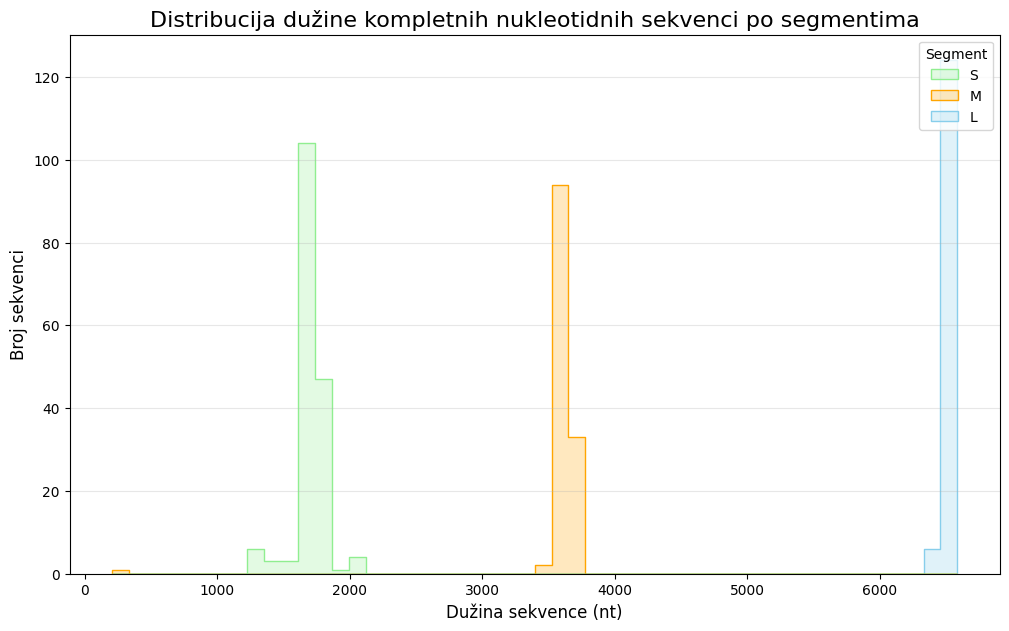

In [63]:
plt.figure(figsize=(12, 7))


sns.histplot(data=complete_sequences, 
             x=complete_sequences['Sequence'].str.len(), 
             hue='Segment', 
             bins=50, 
             kde=False,
             palette={'S': 'lightgreen', 'M': 'orange', 'L': 'skyblue'},
             element='step') 

plt.title('Distribucija dužine kompletnih nukleotidnih sekvenci po segmentima', fontsize=16)
plt.xlabel('Dužina sekvence (nt)', fontsize=12)
plt.ylabel('Broj sekvenci', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [64]:
print(complete_sequences.groupby('Segment')['Sequence'].apply(lambda x: x.str.len().mean()))

Segment
L    6527.815385
M    3598.230769
S    1718.029762
Name: Sequence, dtype: float64


In [65]:
short = complete_sequences[(complete_sequences['Sequence'].str.len() < 1000)]

In [66]:
print(short)

     Unnamed: 0   Accession Segment Nuc_Completeness  \
263         171  KU561220.1       M         complete   

                         Species  \
263  Orthohantavirus dobravaense   

                                              Sequence  
263  ATTTGTCCTGCCCTCAGTCACAGTGTCCTTATTGTTTTACACATTG...  


In [67]:
print(short["Sequence"].str.len())

263    204
Name: Sequence, dtype: int64


In [68]:
complete_sequences = complete_sequences[~((complete_sequences['Accession'] == 'KU561220.1'))]

Proverom distribucije dužina u podskupu kompletnih sekvenci identifikovan je zapis pod accession brojem KU561220.1 (Orthohantavirus dobravaense), koji je u bazi bio označen kao kompletan M segment, iako ima dužinu od svega 204 nt (naspram prosečne dužine M segmenta od oko 3.600 nt). Zbog očigledne greške u anotaciji izvornog zapisa, ova sekvenca je uklonjena iz skupa kompletnih podataka.

In [69]:
all_sequences_clean.to_csv('../data/processed_sequences/final/all_sequences.csv')

In [70]:
complete_sequences.to_csv('../data/processed_sequences/final/complete_sequences.csv')